# Exercise 5: June 13, 2025
# Plotting Vector Fields and Images

**Question 1.** Make an image plot of the function $z(x,y)=\cos{(x)}\cos{(y)}$ with $x$ and $y$ both going from $-\pi/2$ to $\pi/2$. Then plot the vector field $u(x,y)=-y$ and $v(x,y)=x$ on top of this image. Add a colorbar for your image plot and a legend for the vector plot.  

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

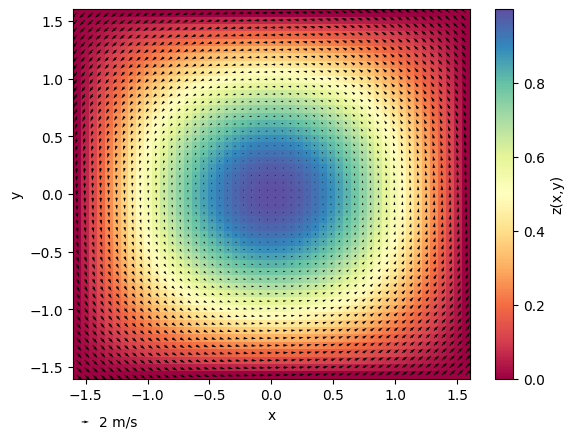

In [ ]:
x = np.linspace(np.pi/(-2), np.pi/2, 50)
y = np.linspace(np.pi/(-2), np.pi/2, 50)
z = np.outer(np.cos(y), np.cos(x))

x_grid, y_grid = np.meshgrid(x,y,indexing="xy")

plt.pcolormesh(x_grid, y_grid, z, cmap="Spectral")
plt.xlabel("x")
plt.ylabel("y")
cb = plt.colorbar()
cb.set_label(label="z(x,y)")

u = -y_grid
v= x_grid

qp = plt.quiver(x_grid, y_grid, u, v)
plt.quiverkey(qp,.15,.02,2, "2 m/s", labelpos="E", coordinates="figure")

plt.show()

**Question 2.** Now we'll plot the velocity field corresponding to the temperature field from the mantle convection image we plotted yesterday. First, make two separate images of horizontal velocity, $u$, and vertical velocity, $w$. These will be two images where the color at each grid point is colored by the velocity.

Use the files u000 and w000 to make these plots. u000 contains horizontal velocity and w000 the vertical velocity. The format for both files is: column 1- x coordinate; column 2- y cooridnate; column 3- velocity (or in Python, this is column 0, 1, and 2 respectively).

A complication to watch out for: horizontal velocity, $u$, and vertical velocity, $w$, are defined on different $x,y$ grids. Here's what $x$ and $y$ vectors for these grids look like:

In [ ]:
from google.colab import files
files.upload()
hv = np.loadtxt("u000", usecols=(0,1,2), unpack=True)

Saving u000 to u000 (8)


In [ ]:
from google.colab import files
files.upload()
vv = np.loadtxt("w000", usecols=(0,1,2), unpack=True)

Saving w000 to w000 (8)


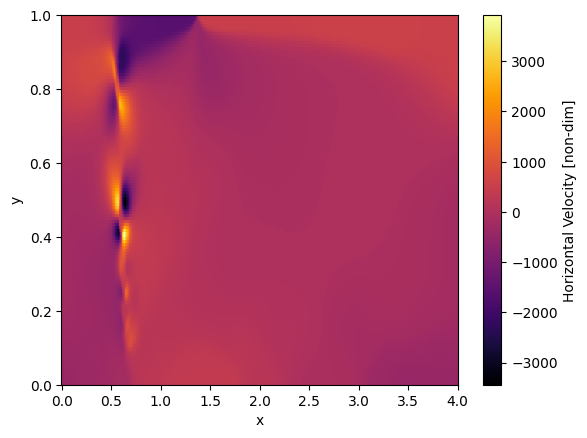

In [ ]:
# Grid for horizontal velocity
x_u=np.linspace(0,4,513)
y_u=np.linspace(0+1/256,1-1/256,128)

xu_grid, yu_grid = np.meshgrid(x_u,y_u,indexing="xy")
u = -yu_grid
h_vel = hv[2]
hvel_grid = np.reshape(h_vel, (128,513), order="F")

plt.pcolormesh(xu_grid, yu_grid, hvel_grid, cmap="inferno")
plt.xlabel("x")
plt.ylabel("y")
cb = plt.colorbar()
cb.set_label(label="Horizontal Velocity [non-dim]")

plt.show()

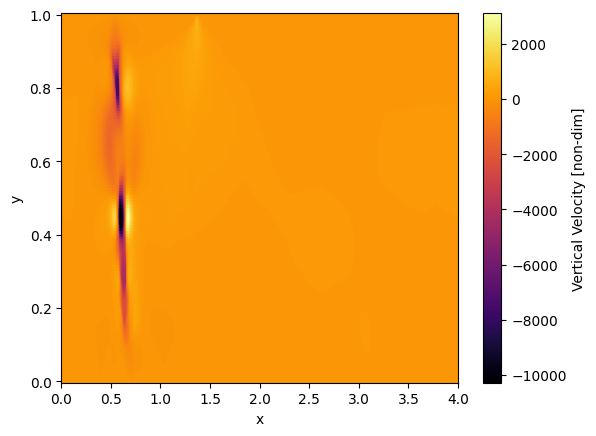

In [ ]:
# Grid for vertical velocity
x_w=np.linspace(0+1/256,4-1/256,512)
y_w=np.linspace(0,1,129)

xw_grid, yw_grid = np.meshgrid(x_w,y_w,indexing="xy")
v = xw_grid
v_vel = vv[2]
vvel_grid = np.reshape(v_vel, (129,512), order="F")

plt.pcolormesh(xw_grid, yw_grid, vvel_grid, cmap="inferno")
plt.xlabel("x")
plt.ylabel("y")
cb = plt.colorbar()
cb.set_label(label="Vertical Velocity [non-dim]")

plt.show()

The grid for temperature, like you plotted yesterday, is:

In [ ]:
from google.colab import files
files.upload()
convection = np.loadtxt("f000", usecols=(0,1,2,5), unpack=True)

Saving f000 to f000 (9)


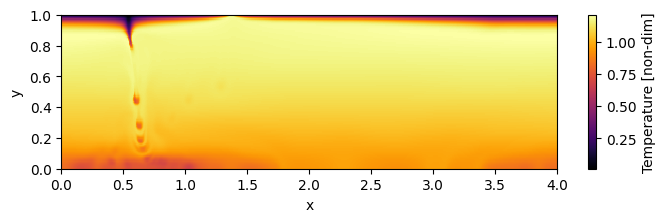

In [ ]:
# Grid for temperature
x = np.linspace(0+1/256,4-1/256,512)
y = np.linspace(0+1/256,1-1/256,128)
temp = convection[2]

x_grid, y_grid = np.meshgrid(x, y, indexing="xy")
temp_grid = np.reshape(temp, (128,512), order="F")

plt.figure(figsize=(8,2))
plt.pcolormesh(x_grid, y_grid, temp_grid, cmap="inferno")
plt.xlabel("x")
plt.ylabel("y")
cb = plt.colorbar()
cb.set_label(label="Temperature [non-dim]")

plt.show()

This just means that when you use `meshgrid` to make the $x$ and $y$ grid to plot the images, you will use `x_u` and `y_u` as defined above for the plot of horizontal velocity, and `x_w` and `y_w` for the veritical velocity plot.

Also, when you create 2-D arrays of horizontal velocity and then vertical velocity in order to plot them, they will have different shapes. Horizontal velocity will have 128 rows and 513 columns (one more than for temperature and viscosity yesterday), and vertical velocity will have 129 rows and 512 columns.

**Question 3.** Now make an image plot for temperature, like we did last exercise, and add vectors for the velocity field. Since $u$ and $w$ and defined on different grids, you will need to interpolate the values onto the same $x,y$ grid. The easiest choice is to interpolate both onto the same grid used for temperature, and can use `griddata` to do this like with the topographic map yesterday.

You will want to experiment with how many vectors to plot to make the figure readable. If you plot an arrow at each grid point, the resulting figure will probably be unreadable, with too many arrows crowding the figure!

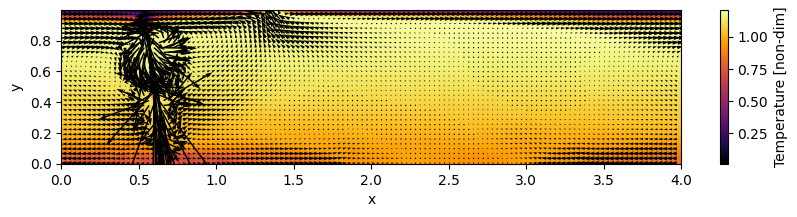

In [ ]:
x, y = convection[0][0::128], convection[1][0:128]
x2, y2 = np.linspace(0+1/256,4-1/256,512), np.linspace(0+1/256,1-1/256,128)

temp = convection[2]
h_vel, v_vel = hv[2], vv[2]


x_grid, y_grid = np.meshgrid(x, y, indexing="xy")
x_grid2, y_grid2 = np.meshgrid(x2[::4], y2[::4], indexing="xy")

temp_grid = np.reshape(temp, (128,512), order="F")
hvel_grid = griddata((hv[0], hv[1]), h_vel, (x_grid2,y_grid2), method="linear")
vvel_grid = griddata((vv[0], vv[1]), v_vel, (x_grid2,y_grid2), method="linear")


plt.figure(figsize=(10,2))
plt.pcolormesh(x_grid, y_grid, temp_grid, cmap="inferno")
plt.xlabel("x")
plt.ylabel("y")
cb = plt.colorbar()
cb.set_label(label="Temperature [non-dim]")

plt.quiver(x_grid2, y_grid2, hvel_grid, vvel_grid)
plt.show()

Here's examples of what the plots should look like:

Question 1

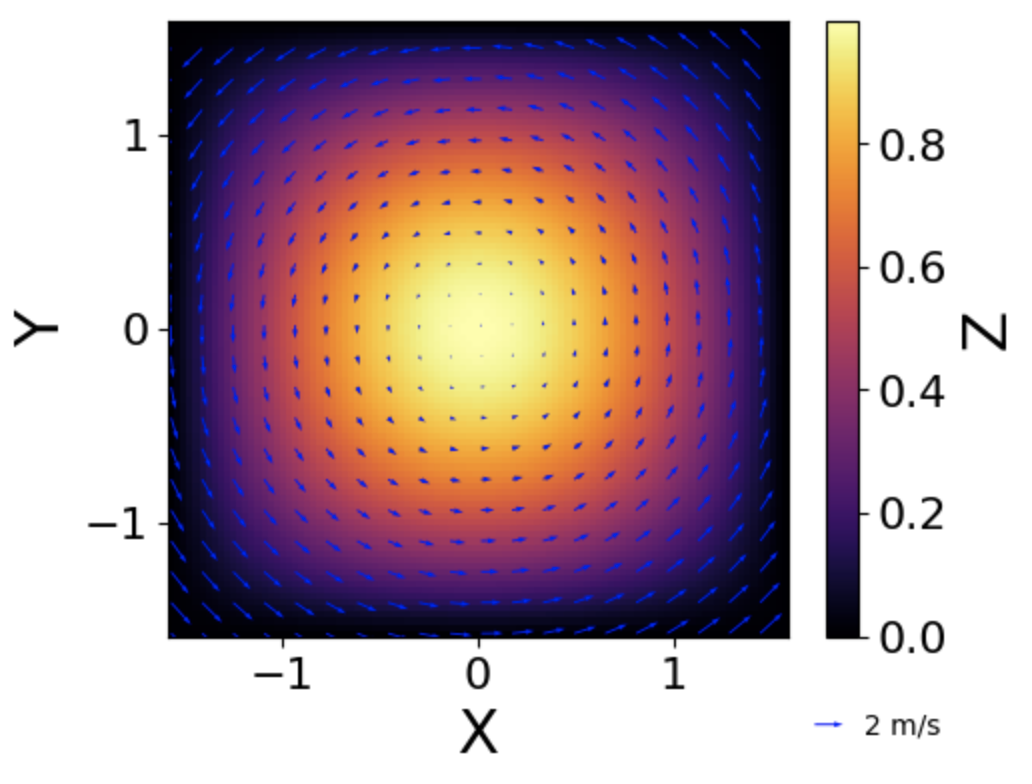





Question 2

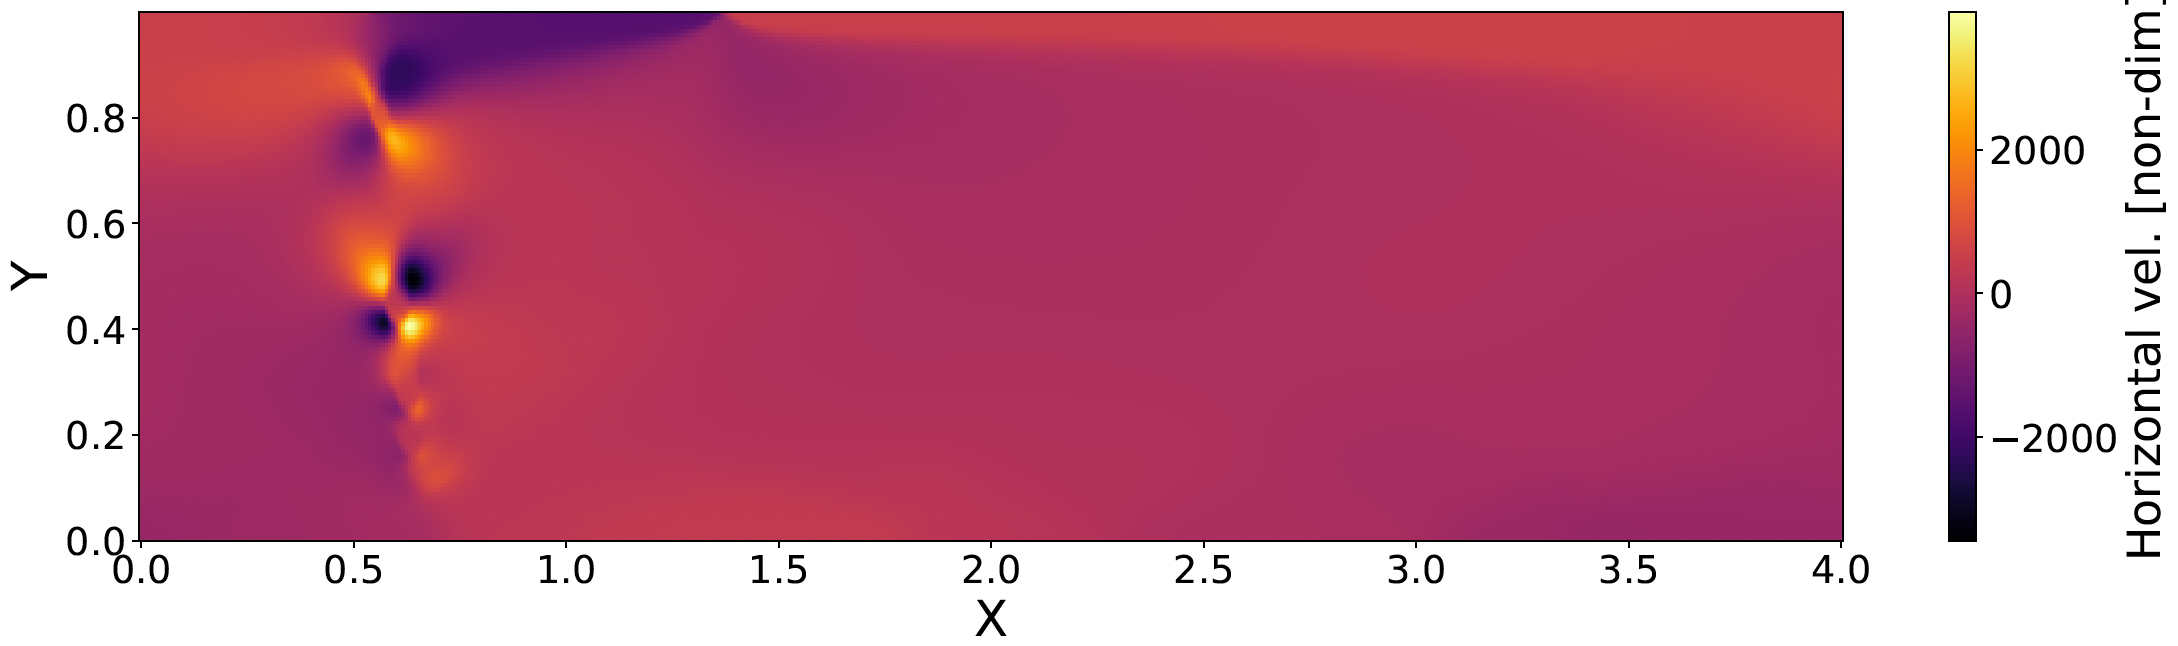


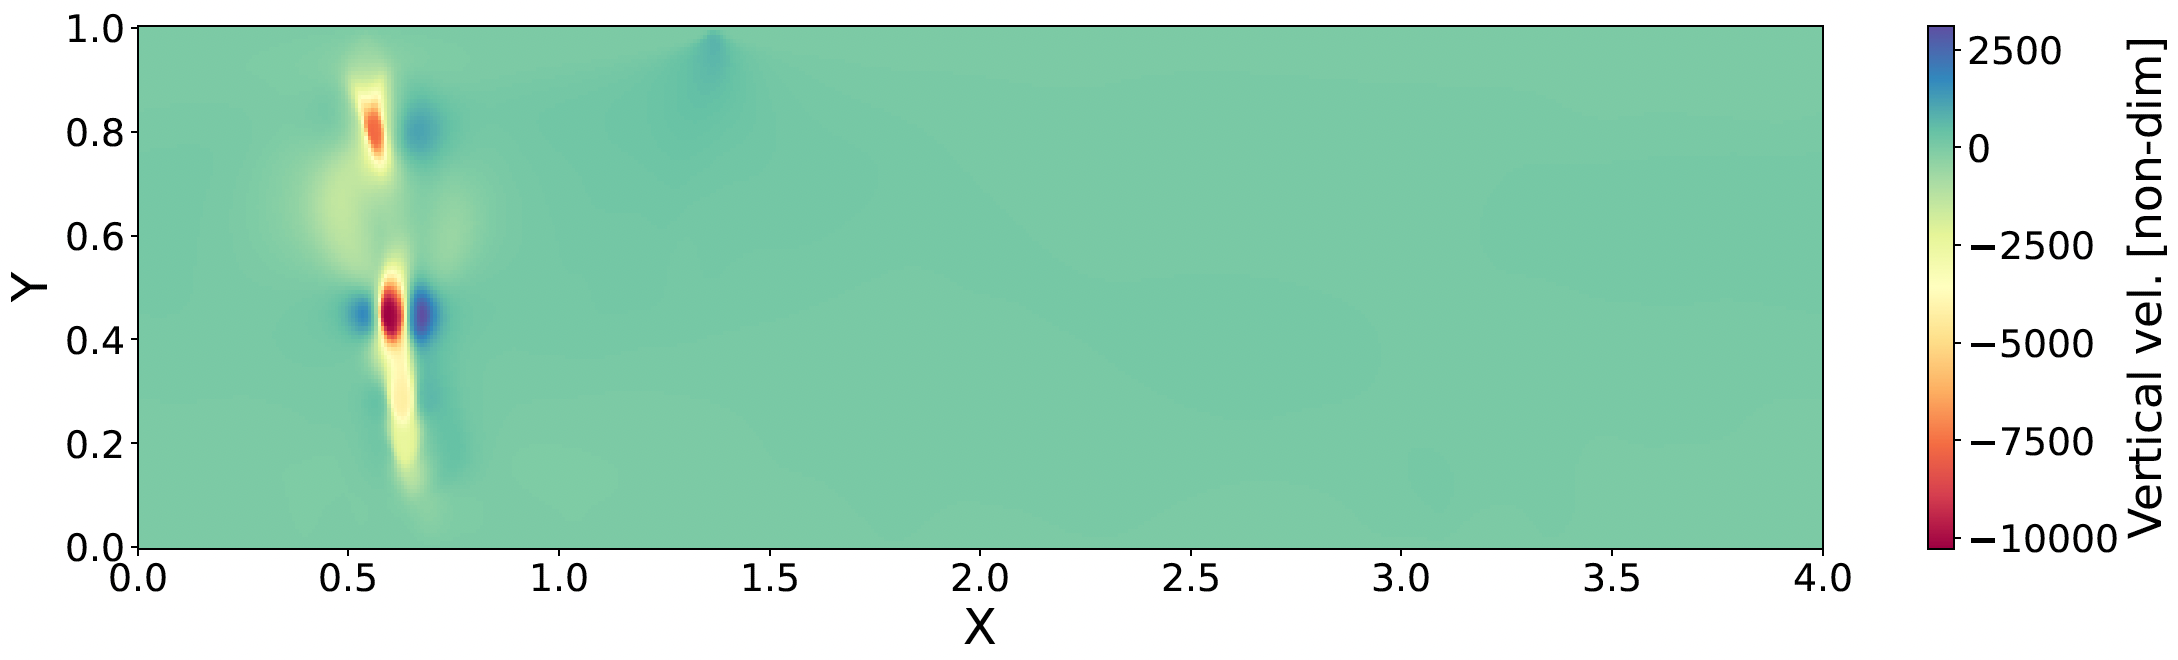

Question 3

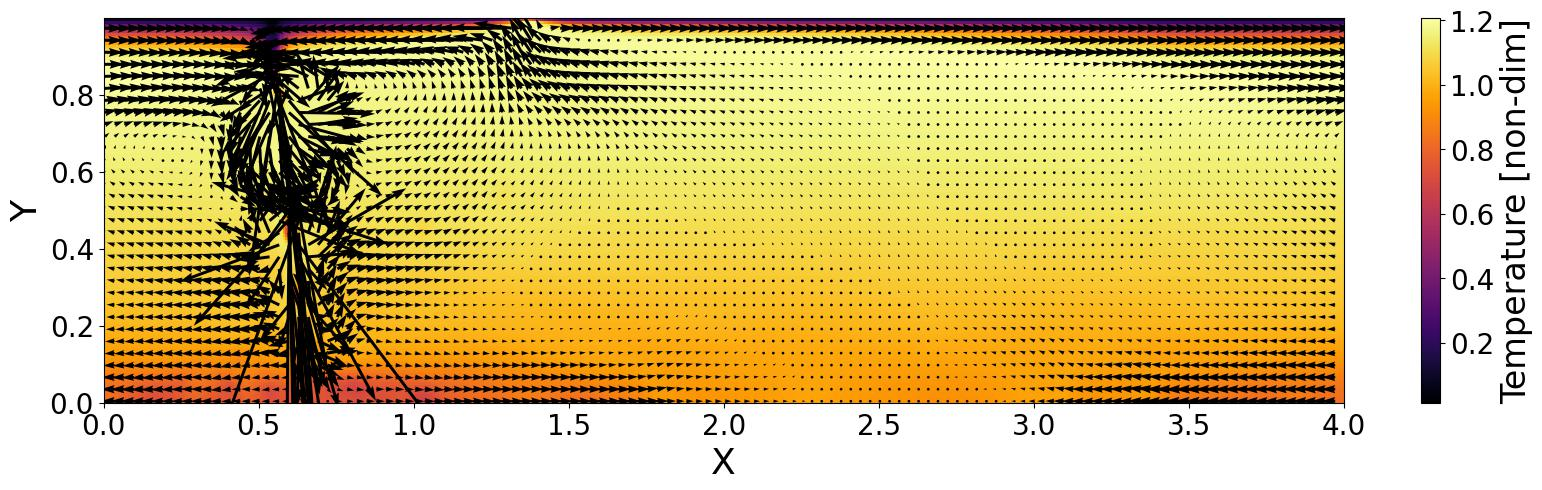